# This is a test run for extracting pich contour from a Hungarian spoken sentence and transcripting it to melody

In [55]:
# importing necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import parselmouth as pm
import librosa as lr
from IPython.display import Audio
from scipy.signal import argrelextrema
import soundfile as sf

### Test with librosa

In [ ]:
# Load the audio file for testing
# Assign path -- Home
# MEgjegyzés: a mappában el van írva a fájlnév a ".waw" a fájlnév végén nem a valós kiterjesztésként működik: valójában a fájlnév így jelenik meg emiatt: ".waw.wav"
filename = "data/Herpai_Julia_eso_24.wav"


# Load the audio and store it as a numpy array
y, sr = lr.load(filename, sr=None)

# Check the output
print(f"Audio Data Shape: {y.shape}")  # NumPy array of audio samples
print(f"Sample Rate: {sr} Hz")  # Sampling rate (e.g., 44,100 Hz)
print(f"Duration: {len(y)/sr:.2f} seconds")

# Display the audio
Audio(y, rate=sr) #Jó reszelős hangja van, nem csodálom, hogy annyi zörejt talált benne az algoritmus


Audio Data Shape: (85458,)
Sample Rate: 44100 Hz
Duration: 1.94 seconds


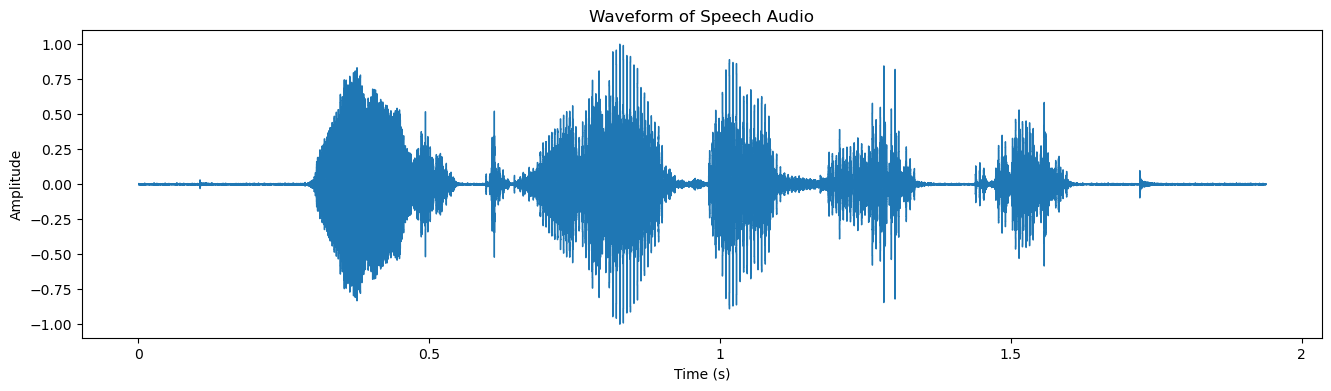

In [3]:
# Visualize time-amplitude domain waveform
plt.figure(figsize=(16, 4))
lr.display.waveshow(y, sr=sr)
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.title("Waveform of Speech Audio")
plt.show()

Text(0.5, 1.0, 'Mel Spectrogram')

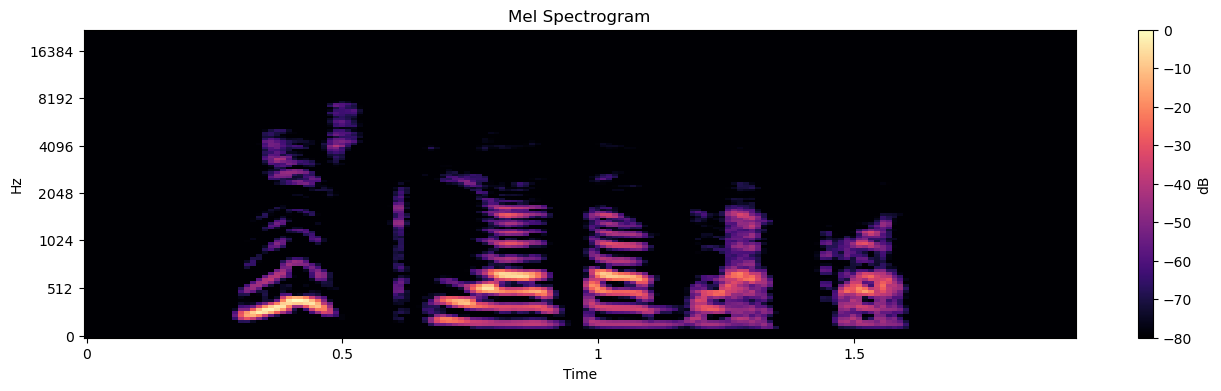

In [4]:
# Compute Mel Spectrogram
mel_spec = lr.feature.melspectrogram(y=y, sr=sr, n_mels=128)

# Convert to dB scale (for better visualization)
mel_spec_db = lr.amplitude_to_db(mel_spec, ref=np.max)

# Plot Mel Spectrogram
plt.figure(figsize=(16, 4))
lr.display.specshow(mel_spec_db, sr=sr, x_axis="time", y_axis="mel")
plt.colorbar(label="dB")
plt.title("Mel Spectrogram")

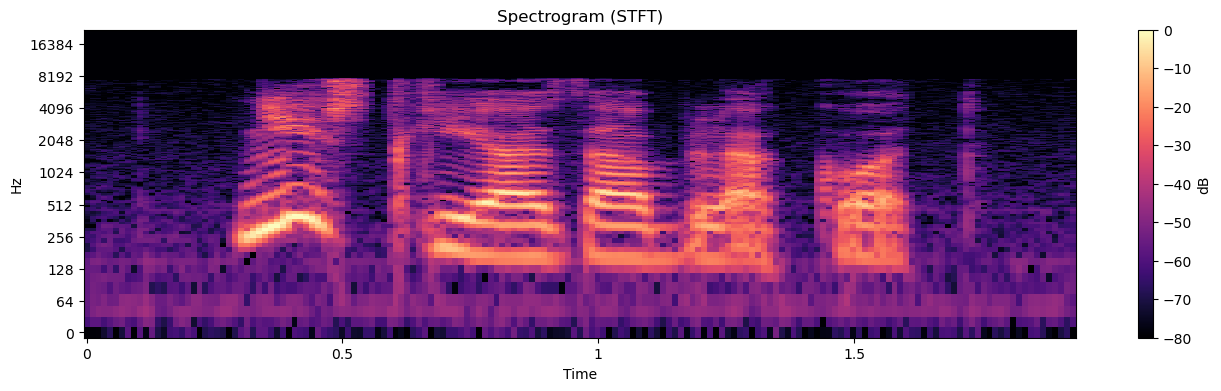

In [5]:
# Perform STFT and convert it to dB
D = lr.amplitude_to_db(np.abs(lr.stft(y,
                                      hop_length=512
                                      )),
                       ref=np.max)


# Show spectrogram
plt.figure(figsize=(16, 4))
lr.display.specshow(D, sr=sr, x_axis="time", y_axis="log")
plt.colorbar(label="dB")
plt.title("Spectrogram (STFT)")
plt.show()


C:\Users\Nagy Sándor Imre\AppData\Local\Temp\ipykernel_3360\3546695184.py:4: UserWarning: With fmin=65.406, sr=44100 and frame_length=676, less than two periods of fmin fit into the frame, which can cause inaccurate pitch detection. Consider increasing to fmin=130.473 or frame_length=1351.
  f0, voiced_flag, voiced_probs = lr.pyin(y,


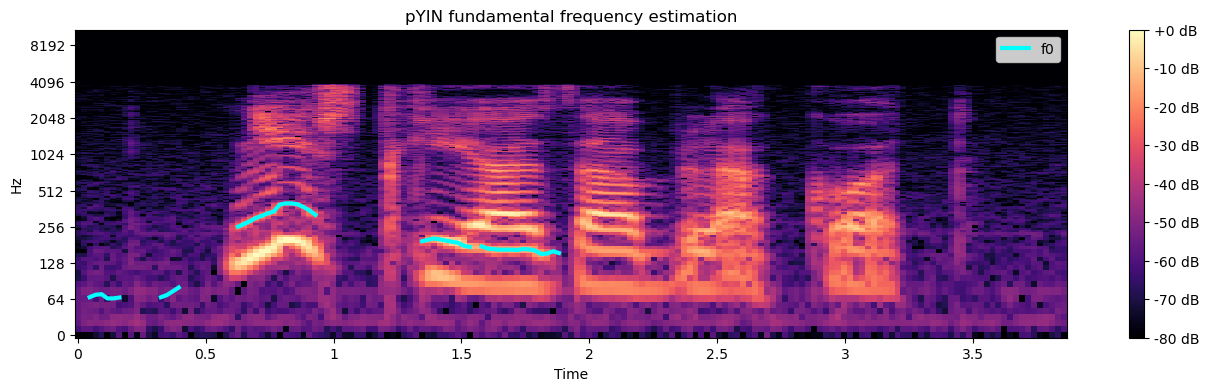

In [7]:
# Extract f0 curve from signal
hop_length = 512  

f0, voiced_flag, voiced_probs = lr.pyin(y,
                                        sr=sr,
                                        frame_length=676,
                                        hop_length=hop_length,
                                        switch_prob=0.3,
                                        fmin=lr.note_to_hz('C2'),
                                        fmax=lr.note_to_hz('C7')
                                        )

# Time axis for the spectrogram (this corresponds to the frames of the spectrogram)
times_spec = lr.times_like(f0, sr=sr, hop_length=hop_length)

# Interpolate the f0 values to match the time axis of the spectrogram
f0_interpolated = np.interp(times_spec, lr.times_like(f0), f0)

# Display pitch contour over spectrogram 
fig, ax = plt.subplots(figsize=(16, 4))
img = lr.display.specshow(D, x_axis='time', y_axis='log', ax=ax)
ax.set(title='pYIN fundamental frequency estimation')
fig.colorbar(img, ax=ax, format="%+2.f dB")
ax.plot(times_spec, f0_interpolated, label='f0', color='cyan', linewidth=3)
ax.legend(loc='upper right')

In [8]:
print("length of audio: ", len(y))
print("length of f0 data: ", len(f0))
print("number of NANs in the f0 array: ", np.sum(np.isnan(f0)))

length of audio:  85458
length of f0 data:  167
number of NANs in the f0 array:  73


#### This doesn't look good, it was only able to draw the pitch contour on a few parts of the signal, and there was even a problem with putting the segments back. At lest, the existing contour aligns with the one generated by Praat. From 167 frames 100 were NaNs. I tried it with several parameters, e.g. hop_length, frame_length, switch prob, but didn't make it better.

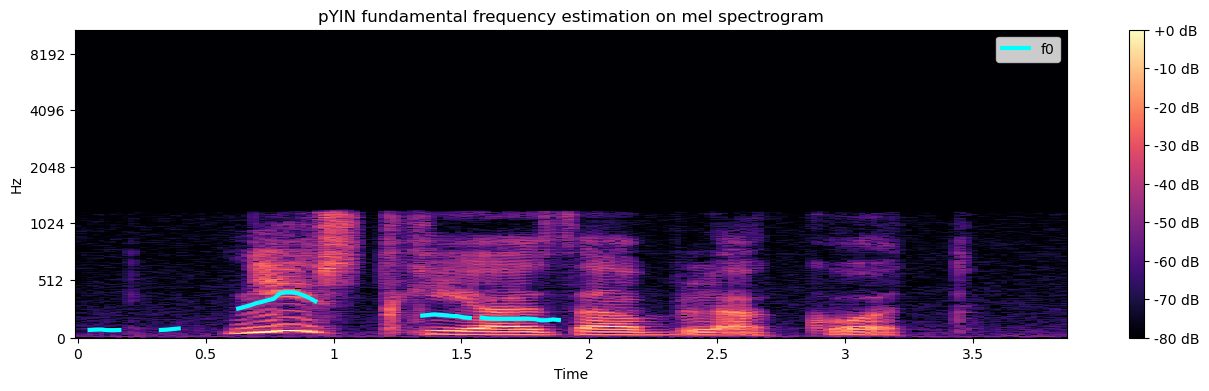

In [9]:
# Using mel_spec_db
# Extract f0 curve from signal
f0_mel, voiced_flag_mel, voiced_probs_mel = lr.pyin(y,
                                        sr=sr,
                                        hop_length=512,
                                        fmin=lr.note_to_hz('C2'),
                                        fmax=lr.note_to_hz('C7'))

# Time axis for the spectrogram (this corresponds to the frames of the spectrogram)
times_spec_mel = lr.times_like(f0_mel, sr=sr, hop_length=512)

# Interpolate the f0 values to match the time axis of the spectrogram
f0_interpolated_mel = np.interp(times_spec_mel, lr.times_like(f0), f0)

# Display pitch contour over spectrogram 
fig, ax = plt.subplots(figsize=(16, 4))
img = lr.display.specshow(D, x_axis='time', y_axis='mel', ax=ax)
ax.set(title='pYIN fundamental frequency estimation on mel spectrogram')
fig.colorbar(img, ax=ax, format="%+2.f dB")
ax.plot(times_spec_mel, f0_interpolated_mel, label='f0', color='cyan', linewidth=3)
ax.legend(loc='upper right')

#### It didn't become better with Mel spectrum either
In theory:
- pYIN is much more sensitive to noise, returns NAN with higher probability
- Praat uses autcorrelation method, more robust, PRaat is also more frequently used in scientific research

### Test with parselmouth

In [ ]:
# Open audio with parselmouth and create parselmouth sound object
sound = pm.Sound("data/Herpai_Julia_eso_24.wav")


# Display the audio
Audio(sound, rate=44100)


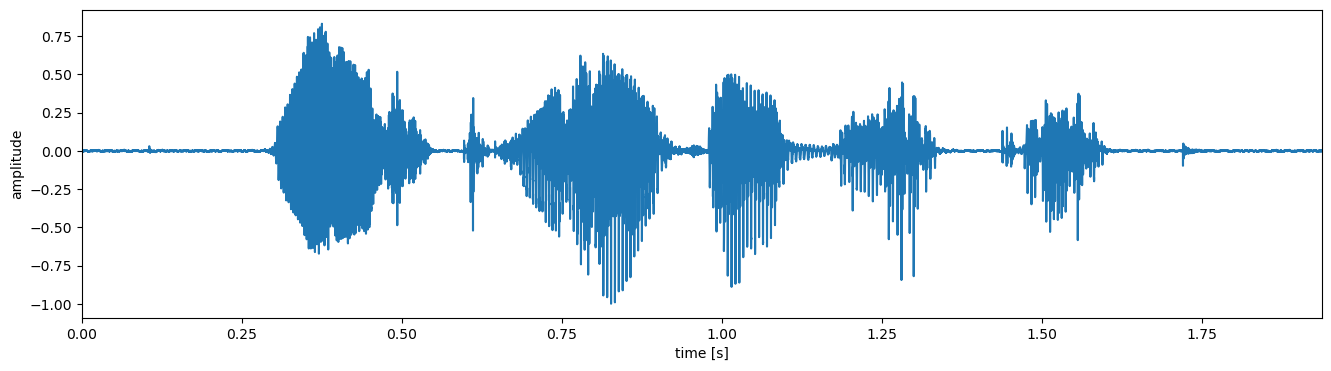

In [11]:
# Visualize waveform
plt.figure(figsize=(16, 4))
plt.plot(sound.xs(), sound.values.T)
plt.xlim([sound.xmin, sound.xmax])
plt.xlabel("time [s]")
plt.ylabel("amplitude")
plt.show()

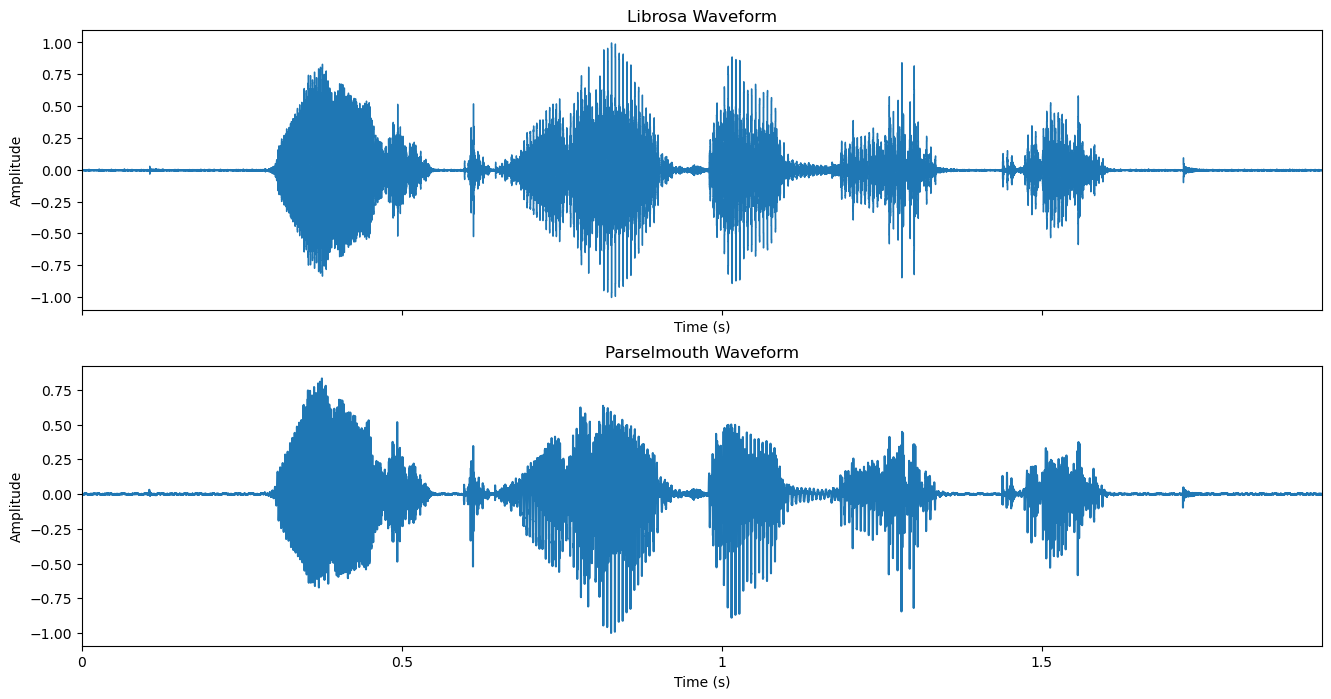

In [12]:
# Compare the two packages' audio outputs
fig, axes = plt.subplots(2, 1, figsize=(16, 8), sharex=True)

# Librosa waveform
axes[0].set_title("Librosa Waveform")
lr.display.waveshow(y, sr=sr, ax=axes[0])
axes[0].set_xlabel("Time (s)")
axes[0].set_ylabel("Amplitude")

# Parselmouth waveform
axes[1].set_title("Parselmouth Waveform")
axes[1].plot(sound.xs(), sound.values.T)
axes[1].set_xlim([sound.xmin, sound.xmax])
axes[1].set_xlabel("Time (s)")
axes[1].set_ylabel("Amplitude")

# Show the figure
plt.show()

In [13]:
# Get sampling frequency
sampling_freq = sound.get_sampling_frequency()

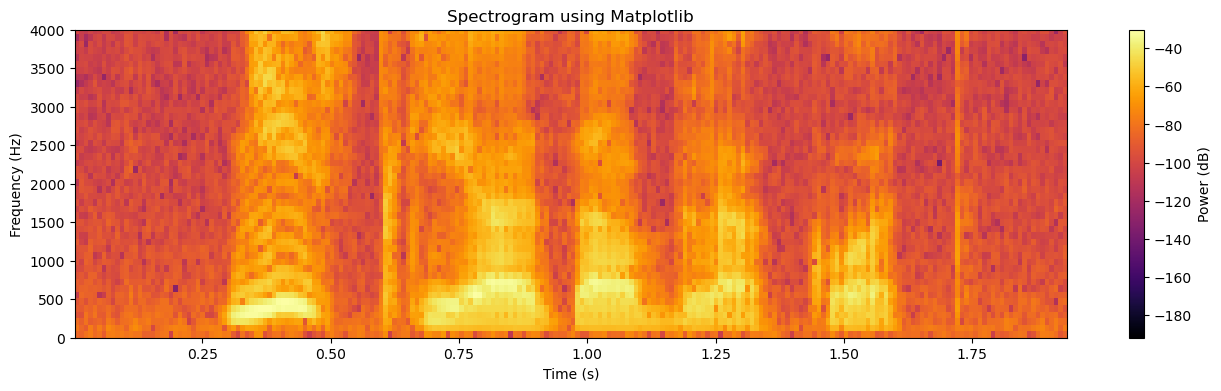

In [14]:
# Visualize spectrogram using matplotlib
plt.figure(figsize=(16, 4))
plt.specgram(sound.values.flatten(), Fs=sampling_freq, NFFT=512, noverlap=128, cmap="inferno")

plt.xlabel("Time (s)")
plt.ylabel("Frequency (Hz)")
plt.ylim(0, 4000)
plt.title("Spectrogram using Matplotlib")
plt.colorbar(label="Power (dB)")
plt.show()



In [15]:
#Create pitch object from sound object
pitch = sound.to_pitch()

# Select pitch values from Pitch object
pitch_array = pitch.selected_array

# Select frequency from pitch array
pitch_values = pitch_array["frequency"]

# Replace zeros with NaNs
pitch_values[pitch_values == 0] = np.nan

# Create time variable for x axis
pitch_time = np.arange(0, len(pitch_array))

In [ ]:
# Plot pitch
plt.figure(figsize=(16, 4))
plt.plot(pitch_time, pitch_values)
plt.show()

#### From parselmouth documentation
https://readthedocs.org/projects/parselmouth/downloads/pdf/latest/

In [16]:
# Define function for drawing spectrogram
def draw_spectrogram(spectrogram, dynamic_range=70):
    X, Y = spectrogram.x_grid(), spectrogram.y_grid()
    sg_db = 10 * np.log10(spectrogram.values)
    plt.pcolormesh(X, Y, sg_db, vmin=sg_db.max() - dynamic_range, cmap='inferno')
    plt.ylim([spectrogram.ymin, spectrogram.ymax])
    plt.xlabel("time [s]")
    plt.ylabel("frequency [Hz]")
    
# Define function for plotting intensity curve
def draw_intensity(intensity):
    plt.plot(intensity.xs(), intensity.values.T, linewidth=3, color='w')
    plt.plot(intensity.xs(), intensity.values.T, linewidth=1)
    plt.grid(False)
    plt.ylim(0)
    plt.ylabel("intensity [dB]")
    
# Define function for plotting pitch contour
def draw_pitch(pitch):
    # Extract selected pitch contour, and
    # replace unvoiced samples by NaN to avoid plotting zeros
    pitch_values = pitch.selected_array['frequency']
    pitch_values[pitch_values==0] = np.nan
    plt.plot(pitch.xs(), pitch_values, '-', linewidth=3, color='b')
    # plt.plot(pitch.xs(), pitch_values, '-', markersize=2)
    plt.grid(False)
    plt.ylim(0, pitch.ceiling)
    plt.ylabel("fundamental frequency [Hz]")


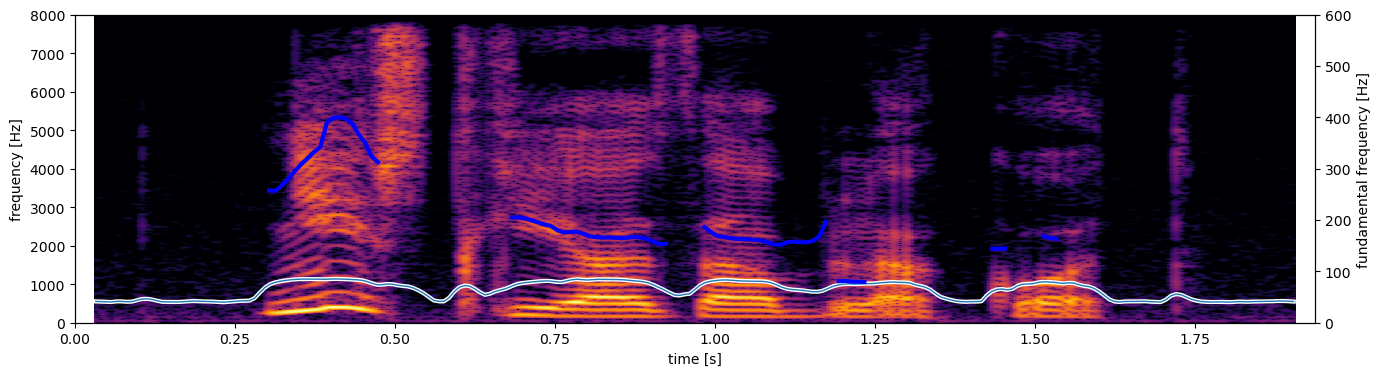

In [17]:
# Create instensity contour
intensity = sound.to_intensity()

# Pre-emphasize sound
pe_sound = sound.copy()
pe_sound.pre_emphasize()

# Create spectrogram
spectrogram = sound.to_spectrogram(window_length=0.03, maximum_frequency=8000)

# Create pitch contour
pitch = sound.to_pitch()

# Plot
plt.figure(figsize=(16, 4))
draw_spectrogram(spectrogram)
plt.twinx()
draw_intensity(intensity)
draw_pitch(pitch)
plt.xlim([sound.xmin, sound.xmax])
plt.show()

### Clean, smooth, interpolate the pitch

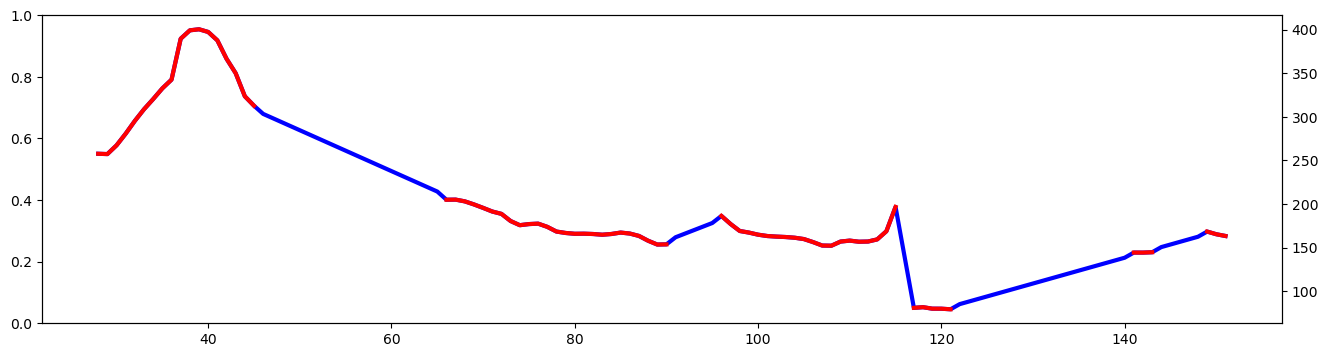

In [18]:
# Interpolate missing values
pitch_interpolated = pitch.interpolate()

# Select pitch values from Pitch object
pitch_int_array = pitch_interpolated.selected_array

# Select frequency from pitch array
pitch_int_values = pitch_int_array["frequency"]

# Replace zeros with NaNs
pitch_int_values[pitch_int_values == 0] = np.nan

# Plot pitch
plt.figure(figsize=(16, 4))
plt.twinx()
plt.plot(pitch_time, pitch_int_values, linewidth=3, color="b")
plt.plot(pitch_time, pitch_values, linewidth=3, color="r")
plt.show()

In [19]:
# Filter sudden jumps in frequency
pitch_octave_filtered = pitch_interpolated.kill_octave_jumps()

# Smooth the signal
pitch_smoothed = pitch_octave_filtered.smooth()

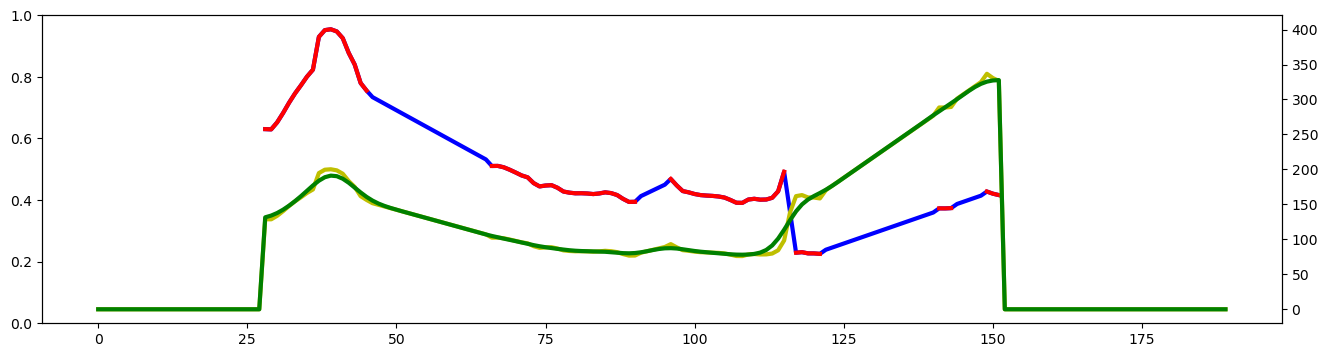

In [20]:
# Visualize the results
plt.figure(figsize=(16, 4))
plt.twinx()
plt.plot(pitch_time, pitch_int_values, linewidth=3, color="b")
plt.plot(pitch_time, pitch_values, linewidth=3, color="r")
plt.plot(pitch_time, pitch_octave_filtered.selected_array["frequency"], linewidth=3, color="y")
plt.plot(pitch_time, pitch_smoothed.selected_array["frequency"], linewidth=3, color="g")
plt.show()

#### Compared to this, the only normal version is the simple interpolated

### Segmenting into syllables using librosa
Previously loaded variables: y=signal, sr=sampling rate

In [21]:
Audio(y, rate=sr)

In [22]:
# Calculate onsets of strength envelope peaks
onset_frames = lr.onset.onset_detect(y=y, sr=sr, backtrack=True)

# Convert onsets to timestamps
onset_times = lr.frames_to_time(onset_frames, sr=sr)

# Display onset times
onset_times


array([0.02321995, 0.1044898 , 0.27863946, 0.33668934, 0.42956916,
       0.47600907, 0.53405896, 0.65015873, 0.95201814, 1.17260771,
       1.24226757, 1.42802721, 1.47446712, 1.54412698, 1.69505669])

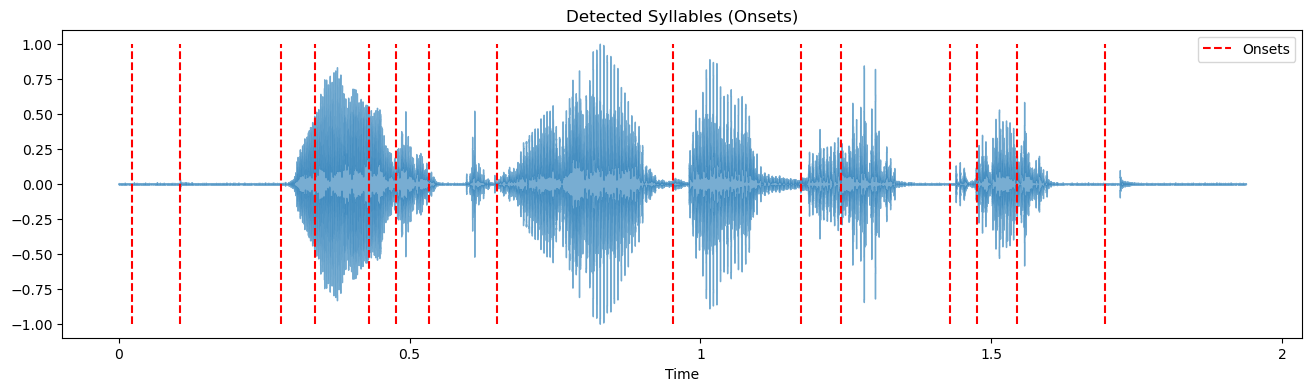

In [23]:
# Plot detected onsets
plt.figure(figsize=(16, 4))
lr.display.waveshow(y, sr=sr, alpha=0.6)
plt.vlines(onset_times, ymin=-1, ymax=1, color='r', linestyle='--', label="Onsets")
plt.legend()
plt.title("Detected Syllables (Onsets)")
plt.show()

In [24]:
# Extract pitch from each segment
syllable_pitches =[]
syllable_onsets = []

for i in range(len(onset_times) - 1):
    start, end = lr.time_to_samples([onset_times[i], onset_times[i + 1]], sr=sr)
    # Extract syllable segment
    syllable_segment = y[start:end]
    # Extract pitch from segment
    f0, voiced_flag, voiced_probs = lr.pyin(syllable_segment, 
                                             fmin=lr.note_to_hz('C2'), 
                                             fmax=lr.note_to_hz('C7'))
    # Calculate median pitch for segment
    syllable_pitch = np.nanmedian(f0) # np.nanmedian() ignores NaN values, while np.median() would result in NaN if the array contains NaNs
    # Store segment median pitch
    syllable_pitches.append(syllable_pitch)
    # Store segment onset time
    syllable_onsets.append(onset_times[i])

    
    
print("Pitch per syllable:", syllable_pitches)

    


C:\Users\Nagy Sándor Imre\AppData\Local\Temp\ipykernel_3360\3815170055.py:14: RuntimeWarning: All-NaN slice encountered
  syllable_pitch = np.nanmedian(f0) # np.nanmedian() ignores NaN values, while np.median() would result in NaN if the array contains NaNs


Pitch per syllable: [np.float64(nan), np.float64(70.91536696417685), np.float64(133.48486815894358), np.float64(182.87233715141332), np.float64(182.87233715141332), np.float64(nan), np.float64(nan), np.float64(85.56292308303966), np.float64(80.9911881955289), np.float64(80.5247132770094), np.float64(nan), np.float64(72.15494574405967), np.float64(82.64557835465958), np.float64(nan)]


#### Its not too succesful, so far, there are too many segments, let's try to combine librosa with parselmouth
- Librosa -> onset detection
- Parselmouth -> extract pitch from onset-onset windows

- librosa vars: y, sr; parselmouth vars: sound
- previous onset detection resulted in more segments then the actual number of syllables --> need stronger criteria

In [ ]:
# Reload audio signal
sound = pm.Sound("data/Herpai_Julia_eso_24.wav")

In [ ]:
# Extract tempo just out of curiosity
tempo = lr.feature.tempo(y=y, sr=sr)

# Show estimated tempo of the audio
print("Estimated tempo: ", tempo[0].round(2))

Estimated tempo:  156.61


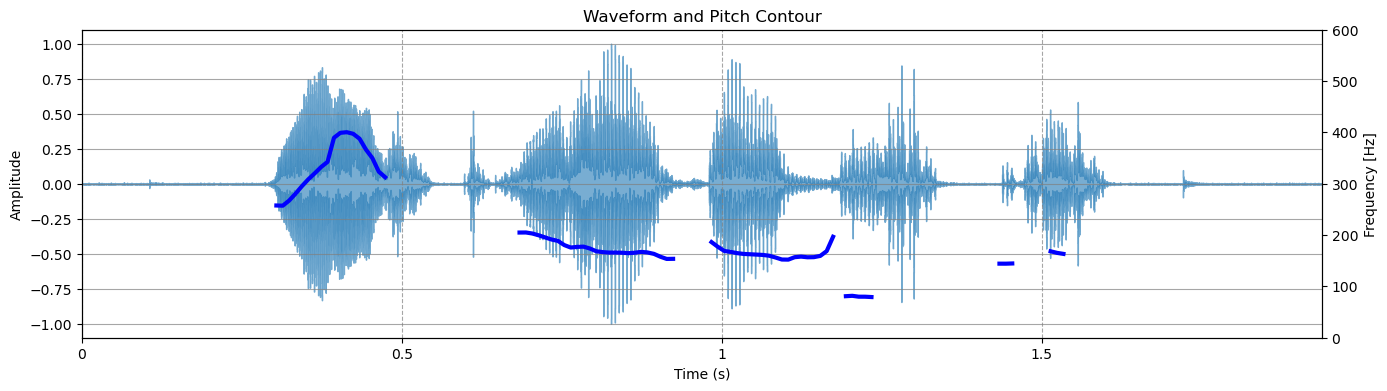

In [27]:
# Create pitch contour
pitch = sound.to_pitch_ac()


# Create the first figure
fig, ax1 = plt.subplots(figsize=(16, 4))
    
pitch_values = pitch.selected_array['frequency']
pitch_values[pitch_values == 0] = np.nan
    
# Plot the waveform on the first y-axis (left)
lr.display.waveshow(y, sr=sr, alpha=0.6, ax=ax1, label="Waveform")
ax1.set_xlabel("Time (s)")
ax1.set_ylabel("Amplitude")
ax1.set_xlim([0, len(y) / sr])  # Set x limits according to audio duration

# Create a second y-axis for pitch
ax2 = ax1.twinx()
    
# Plot pitch on the second y-axis (right)
ax2.plot(pitch.xs(), pitch_values, '-', linewidth=3, color='b', label="Pitch Contour")
ax2.set_ylabel("Frequency [Hz]")
ax2.set_ylim(0, pitch.ceiling)  # Set y limits according to pitch ceiling

# Display the plot
plt.title("Waveform and Pitch Contour")
# Add grid lines (vertical and horizontal)
ax1.grid(True, which='both', axis='x', linestyle='--', color='gray', alpha=0.7)  # Vertical grid lines
ax1.grid(True, which='both', axis='y', linestyle='-', color='gray', alpha=0.7)  # Horizontal grid lines

plt.show()




In [28]:
# Calculate onset envelope
onset_env = lr.onset.onset_strength(y=y, sr=sr)

# Create time axis for the onset envelope (convert frames to seconds)
onset_times = lr.times_like(onset_env, sr=sr)

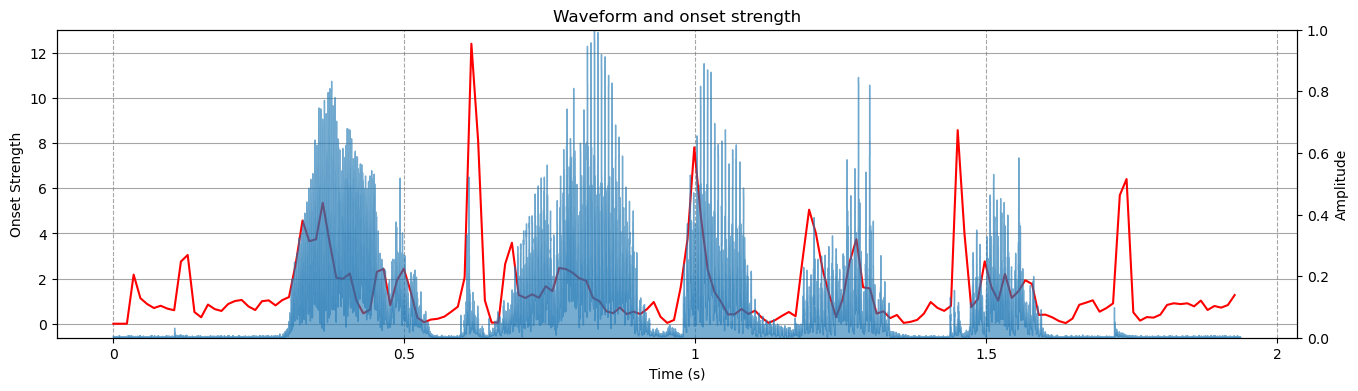

In [29]:
# Visualize onset envelope with waveform
fig, ax1 = plt.subplots(figsize=(16, 4))


# Create first plot: onset envelope
ax1.plot(onset_times, onset_env, color="r")
ax1.set_xlabel("Time (s)")
ax1.set_ylabel("Onset Strength")
#ax1.set_ylim(-1, 1)

# Create second plot: waveform
ax2 = ax1.twinx()

lr.display.waveshow(y, sr=sr, alpha=0.6, ax=ax2, label="Waveform")
ax2.set_ylabel("Amplitude")
ax2.set_ylim(0, 1)

# Display the plot
plt.title("Waveform and onset strength")
# Add grid lines (vertical and horizontal)
ax1.grid(True, which='both', axis='x', linestyle='--', color='gray', alpha=0.7)  # Vertical grid lines
ax1.grid(True, which='both', axis='y', linestyle='-', color='gray', alpha=0.7)  # Horizontal grid lines
plt.show()



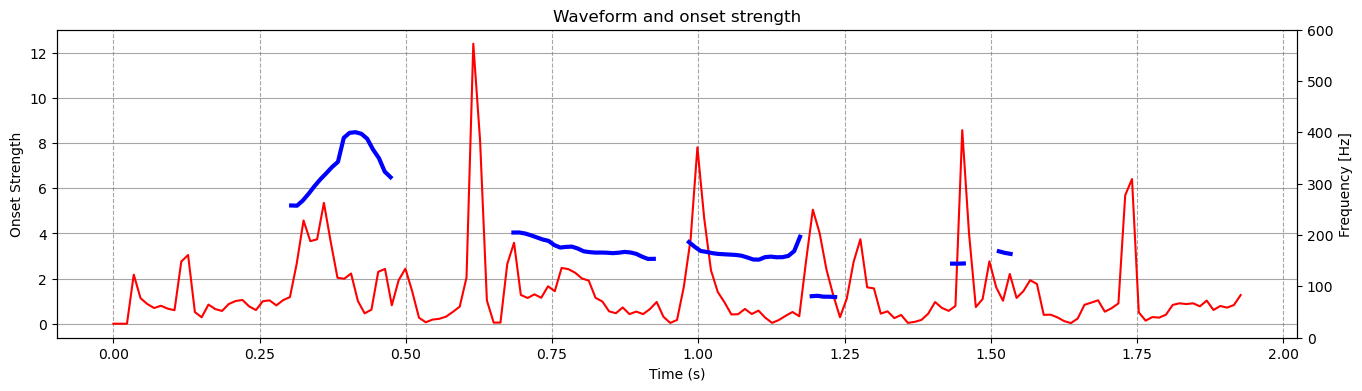

In [30]:
# Visualize onset envelope with pitch
fig, ax1 = plt.subplots(figsize=(16, 4))


# Create first plot: onset envelope
ax1.plot(onset_times, onset_env, color="r")
ax1.set_xlabel("Time (s)")
ax1.set_ylabel("Onset Strength")
# ax1.set_ylim()

# Create second plot: waveform
ax2 = ax1.twinx()

# Plot pitch on the second y-axis (right)
ax2.plot(pitch.xs(), pitch_values, '-', linewidth=3, color='b', label="Pitch Contour")
ax2.set_ylabel("Frequency [Hz]")
ax2.set_ylim(0, pitch.ceiling)  # Set y limits according to pitch ceiling

# Display the plot
plt.title("Waveform and onset strength")
# Add grid lines (vertical and horizontal)
ax1.grid(True, which='both', axis='x', linestyle='--', color='gray', alpha=0.7)  # Vertical grid lines
ax1.grid(True, which='both', axis='y', linestyle='-', color='gray', alpha=0.7)  # Horizontal grid lines
plt.show()

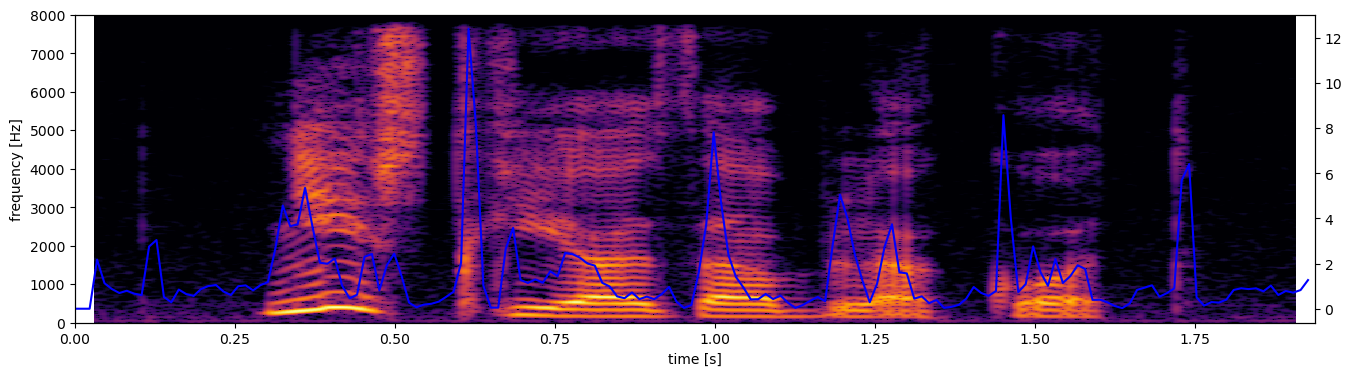

In [31]:
# Visualize spectrogram and onset envelope
plt.figure(figsize=(16, 4))
draw_spectrogram(spectrogram)
plt.twinx()
plt.plot(onset_times, onset_env, color="b")
plt.xlim([sound.xmin, sound.xmax])


plt.show()

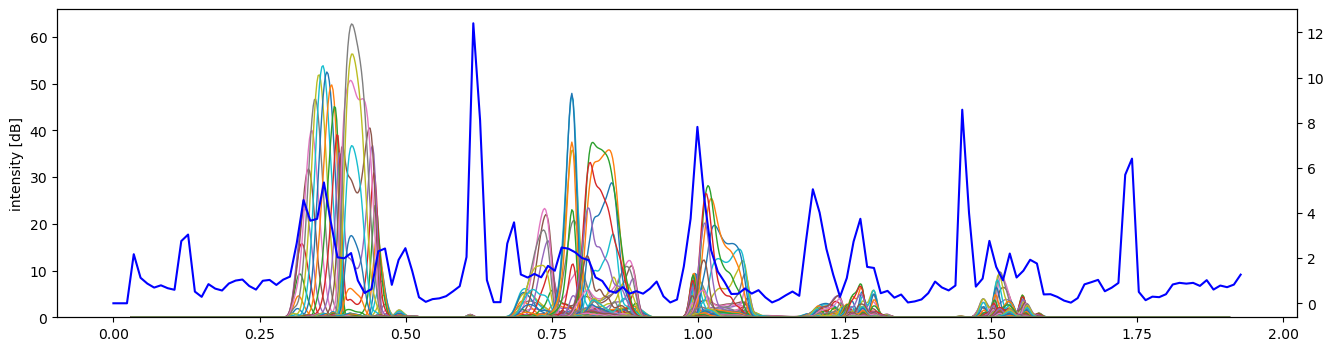

In [32]:
# Visualize spectrogram and onset envelope
plt.figure(figsize=(16, 4))
draw_intensity(spectrogram)
plt.twinx()
plt.plot(onset_times, onset_env, color="b")
plt.show()

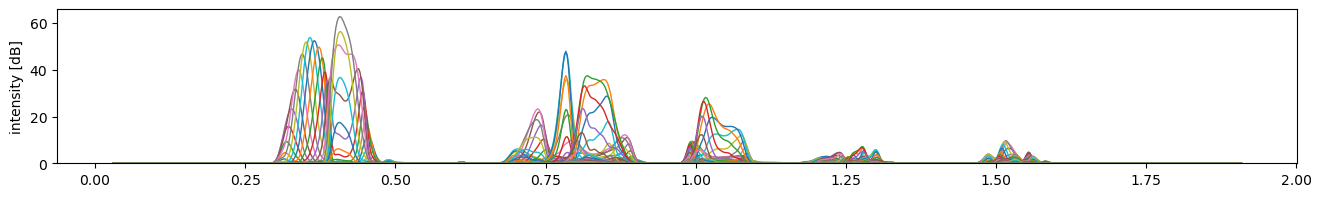

In [33]:
# Visualize only the intensity
plt.figure(figsize=(16, 2))
draw_intensity(spectrogram)

In [34]:
# Calculate intensity
intensity = sound.to_intensity()

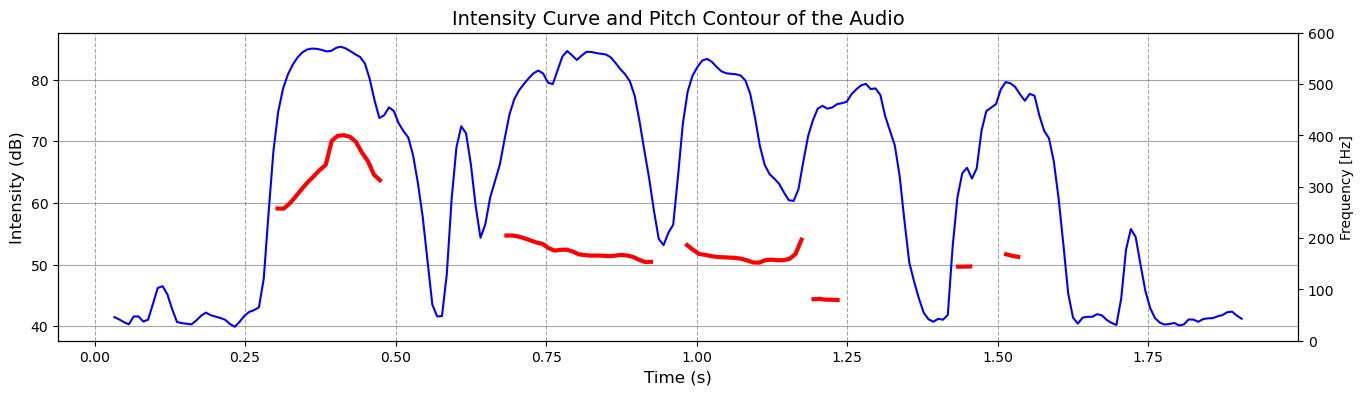

In [35]:
# Visualize pitch contour and intensity curve
intensity_values = np.array(intensity.values).flatten()
time = np.array(intensity.xs())

# Plot the intensity curve
fig, ax1 = plt.subplots(figsize=(16, 4))
ax1.plot(time, intensity_values, label="Intensity", color='blue')
ax1.set_xlabel("Time (s)", fontsize=12)
ax1.set_ylabel("Intensity (dB)", fontsize=12)
# Plot pitch contour
ax2 = ax1.twinx()
# Plot pitch on the second y-axis (right)
ax2.plot(pitch.xs(), pitch_values, '-', linewidth=3, color='r', label="Pitch Contour")
ax2.set_ylabel("Frequency [Hz]")
ax2.set_ylim(0, pitch.ceiling)  # Set y limits according to pitch ceiling

#Add title
plt.title("Intensity Curve and Pitch Contour of the Audio", fontsize=14)
# Add grid lines (vertical and horizontal)
ax1.grid(True, which='both', axis='x', linestyle='--', color='gray', alpha=0.7)  # Vertical grid lines
ax1.grid(True, which='both', axis='y', linestyle='-', color='gray', alpha=0.7)  # Horizontal grid lines
plt.show()

#### Based on the plots above, maybe it is worth doing the segmentation from the intensity curve, and finding trough-to-trough segments
- if it doesn't work, then maybe try librosa's onset peak-to-peak
- the latter is a more valid solution
- or based on pitch-to-pitch averaging? 

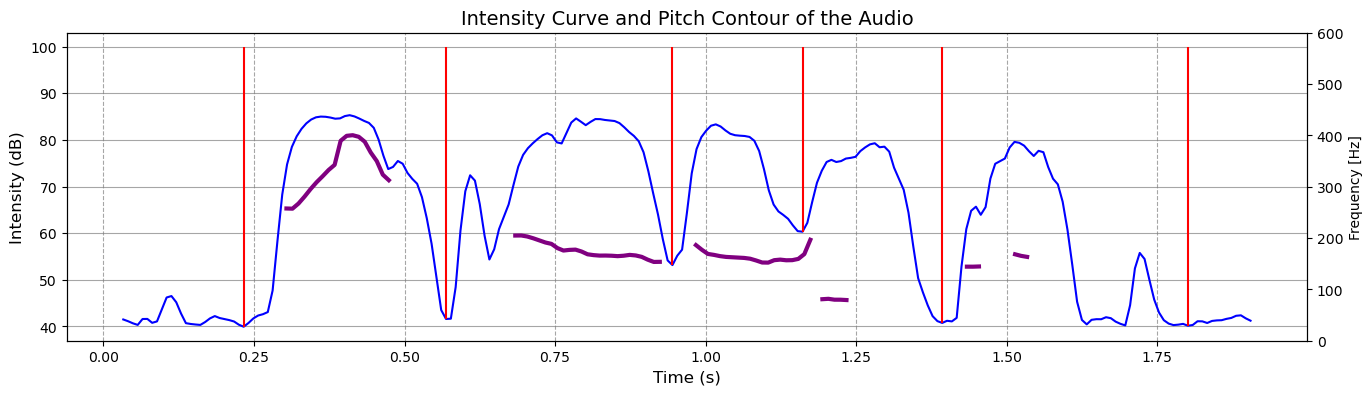

In [ ]:
# From ChatGPT
from scipy.signal import argrelextrema
# Find the local minima (troughs) of the intensity curve (RMS)
# 'order=5' means we'll look for minima that have at least 5 neighbors
troughs = argrelextrema(intensity_values, np.less_equal, order=15)[0] # EZ EGY NAGYON FONTOS KÓDSOR!!!!

# Plot the intensity curve
fig, ax1 = plt.subplots(figsize=(16, 4))
ax1.plot(intensity.xs(), intensity_values, label="Intensity", color='blue')
ax1.vlines(time[troughs], intensity_values[troughs], ymax=100, color='red', label='Detected Troughs')
ax1.set_xlabel("Time (s)", fontsize=12)
ax1.set_ylabel("Intensity (dB)", fontsize=12)

# Plot pitch contour
ax2 = ax1.twinx()
# Plot pitch on the second y-axis (right)
ax2.plot(pitch.xs(), pitch_values, '-', linewidth=3, color='purple', label="Pitch Contour")
ax2.set_ylabel("Frequency [Hz]")
ax2.set_ylim(0, pitch.ceiling)  # Set y limits according to pitch ceiling

#Add title
plt.title("Intensity Curve and Pitch Contour of the Audio", fontsize=14)
# Add grid lines (vertical and horizontal)
ax1.grid(True, which='both', axis='x', linestyle='--', color='gray', alpha=0.7)  # Vertical grid lines
ax1.grid(True, which='both', axis='y', linestyle='-', color='gray', alpha=0.7)  # Horizontal grid lines
plt.show()

#### Interestingly this found the 5-6 segments, more or less corresponding to syllables

In [37]:
# Check the trough points in the signal
print("Trough points in intensity curve: ", troughs)
# Concatenate the beginning and endpoint of the signal to the array
segment_boundaries = np.concatenate([[0], troughs, [len(time)-1]])
# Print results
print("Segment boundaries: ", segment_boundaries)

Trough points in intensity curve:  [ 25  67 114 141 170 221]
Segment boundaries:  [  0  25  67 114 141 170 221 234]


In [38]:
# Sanity check
print("Length of intensity curve: ", len(intensity_values))
print("Length of time array: ", len(time))
print("Length of pitch values array: ", len(pitch_values))
print("Length of pitch time indices: ", len(pitch.xs()))
print("Last value of segment_boundaries: ", segment_boundaries[-1])

Length of intensity curve:  235
Length of time array:  235
Length of pitch values array:  190
Length of pitch time indices:  190
Last value of segment_boundaries:  234


In [39]:
# Calculate median pitch in each segment
median_pitches = []

for i in range(len(segment_boundaries) - 1):
    # Set segment start and end points
    segment_start = time[segment_boundaries][i]
    segment_end = time[segment_boundaries][i+1]
    
    # Calculate segment indices -- np.where() returns indices where the defined conditions are true
    segment_indices = np.where((pitch.xs() >= segment_start) & (pitch.xs() < segment_end))
    segment_pitches = pitch_values[segment_indices]
    
    # Calculate nanmedian pitch in segment
    if len(segment_pitches) > 0: # contains at least 1 non-nan value
        median_pitch = np.nanmedian(segment_pitches)
    else:
        median_pitch = 0
    
    # Append aggregated pitch value to list
    median_pitches.append(median_pitch)
    

for i in median_pitches:
    print(i)
    
    

nan
328.0526599323345
168.38778176572686
160.52642383136765
80.89291218627072
153.97004621932626
nan


C:\Users\Nagy Sándor Imre\AppData\Local\Temp\ipykernel_3360\1636292286.py:15: RuntimeWarning: All-NaN slice encountered
  median_pitch = np.nanmedian(segment_pitches)


#### According to ChatGPT it is easier to convert the Hz to MIDI and round, because it is easier to find the exact sound frequencies
- alternative solution: round to cents
- alternative solution 2: round pitch intervals to cents, based on +- 50 cents

In [40]:
# Convert pitch values to MIDI
midi_notes = lr.hz_to_midi(median_pitches)
# Print raw midi notes out
print("Raw MIDI values:")
for i in midi_notes:
    print(i)

# Round midi notes to the nearest semitone
midi_notes_rounded = np.round(midi_notes)
# Print the values
print("Rounded MIDI values:")
for i in midi_notes_rounded:
    print(i)

# Convert back to Hz -- this step is not necessary for sound playback 
quantized_pitches = lr.midi_to_hz(midi_notes_rounded)
#Print values
print("Rounded pitch values:")
for i in quantized_pitches:
    print(i)

Raw MIDI values:
nan
63.91708674160654
52.371407236268595
51.54368725646226
39.67898017236603
50.82175426053122
nan
Rounded MIDI values:
nan
64.0
52.0
52.0
40.0
51.0
nan
Rounded pitch values:
nan
329.6275569128699
164.81377845643496
164.81377845643496
82.4068892282175
155.56349186104046
nan


In [41]:
# Fill up segments with constant pitch values: raw MIDI, rounded MIDI, rounded pitch
def fill_up_segments(segment_boundaries, values, time):
    # Create empty signal (all nans) with length of original array
    signal = np.full_like(time, np.nan, dtype=float)
    
    # Fill the signal with constant values for each corresponding segment
    for i in range(len(segment_boundaries) - 1):
        # Define the rolling windows' start and end points
        segment_start = time[segment_boundaries][i]
        segment_end = time[segment_boundaries][i+1]
        
        # Get the pitch value for the current segment
        segment_value = values[i]
        
        # Find the indices of the time array within this segment
        segment_indices = np.where((time >= segment_start) & (time < segment_end))[0]
        
        # Assign the segment value to the corresponding indices
        signal[segment_indices] = segment_value
        
    # Handle the last segment explicitly to ensure the final boundary is included
    last_segment_indices = np.where(time >= time[segment_boundaries[-1]])[0]
    if len(last_segment_indices) > 0:
        signal[last_segment_indices] = values[-1]
        
    return signal

In [42]:
# Create quantized pitches
quantized = fill_up_segments(segment_boundaries=segment_boundaries,
                                     values=quantized_pitches,
                                     time=time)

# Use median pitches
medians = fill_up_segments(segment_boundaries=segment_boundaries,
                                     values=median_pitches,
                                     time=time)


# midi = fill_up_segments(segment_boundaries=segment_boundaries,
#                        values=midi_notes_rounded,
#                        time=time)

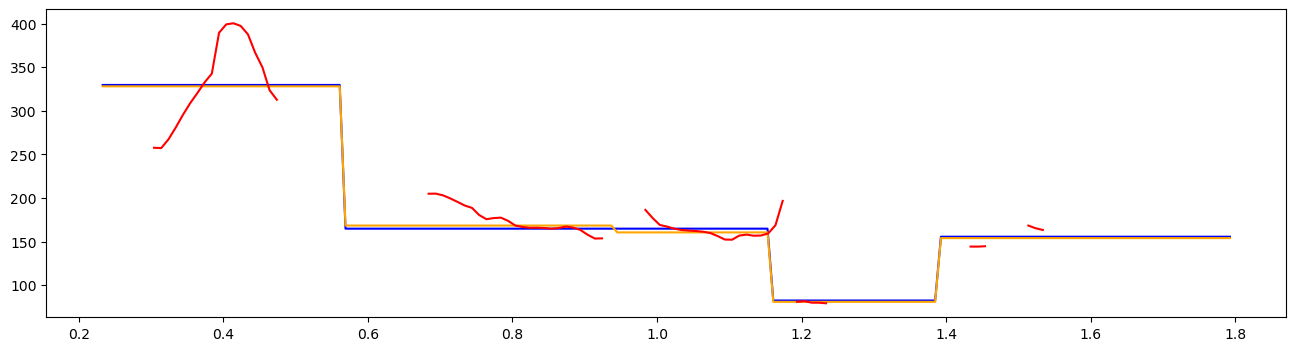

In [43]:
plt.figure(figsize=(16, 4))
plt.plot(time, quantized, color="b")
plt.plot(time, medians, color="orange")
plt.plot(pitch.xs(), pitch_values, color="r")
plt.show()

#### The median pitches and quantized values seem very similar to each other

In [44]:
# Check if arrays are the same within a tolerance
are_equal = np.allclose(quantized, medians, atol=1e-5)
print("Are quantized and medians array the same? ", are_equal)  # True if they are the same within the tolerance

Are quantized and medians array the same?  False


In [45]:
### 2nd version
# Function to synthesize an audio signal from quantized pitch values
def synthesize_audio(input_signal, segment_boundaries, time, sr=44100):
    # Create an empty array to hold the audio signal
    output_signal = np.array([])
    # Convert NaNs to zeros in input signal
    input_signal = np.nan_to_num(input_signal, nan=0)
    # print("Non-nan input signal: ", input_signal)
    
    for i in range(len(segment_boundaries) - 1):
        start_idx = segment_boundaries[i]
        end_idx = segment_boundaries[i+1]
    
        duration = time[end_idx] - time[start_idx] # another solution might be: (end_idx - start_idx) / sampling_rate
        
        print(f"Segment {i}: Start {start_idx}, End {end_idx}, Duration: {time[end_idx] - time[start_idx]:.4f}s")
        pitch = input_signal[start_idx]
        # Generate tone with the given pitch
        if pitch == 0.0:
            sine_wave = np.zeros(int(sr * duration))
            # print(f"Segment {i}: Generated sine wave: {sine_wave}")
        else:    
            sine_wave = lr.tone(frequency=pitch, duration=duration, sr=sr)
            # print(f"Segment {i}: Generated sine wave: {sine_wave}")
        # print(f"Segment {i}: Actual Pitch Value: {pitch}s")
        # Concatenate to output_signal
        output_signal = np.concatenate([output_signal, sine_wave])
        
    return output_signal

In [46]:
synth_quant = synthesize_audio(quantized, segment_boundaries, time=time, sr=44100)

Segment 0: Start 0, End 25, Duration: 0.2000s
Segment 1: Start 25, End 67, Duration: 0.3360s
Segment 2: Start 67, End 114, Duration: 0.3760s
Segment 3: Start 114, End 141, Duration: 0.2160s
Segment 4: Start 141, End 170, Duration: 0.2320s
Segment 5: Start 170, End 221, Duration: 0.4080s
Segment 6: Start 221, End 234, Duration: 0.1040s


In [47]:
Audio(synth_quant, rate=44100)

In [49]:
# Synthetize quantized signal
quantized_audio_signal = synthesize_audio(quantized, segment_boundaries, time=time, sr=44100)

# Synthesize audio from median pitches
median_pitches_audio_signal = synthesize_audio(medians, segment_boundaries, time=time, sr=44100)

Segment 0: Start 0, End 25, Duration: 0.2000s
Segment 1: Start 25, End 67, Duration: 0.3360s
Segment 2: Start 67, End 114, Duration: 0.3760s
Segment 3: Start 114, End 141, Duration: 0.2160s
Segment 4: Start 141, End 170, Duration: 0.2320s
Segment 5: Start 170, End 221, Duration: 0.4080s
Segment 6: Start 221, End 234, Duration: 0.1040s
Segment 0: Start 0, End 25, Duration: 0.2000s
Segment 1: Start 25, End 67, Duration: 0.3360s
Segment 2: Start 67, End 114, Duration: 0.3760s
Segment 3: Start 114, End 141, Duration: 0.2160s
Segment 4: Start 141, End 170, Duration: 0.2320s
Segment 5: Start 170, End 221, Duration: 0.4080s
Segment 6: Start 221, End 234, Duration: 0.1040s


Text(0, 0.5, 'Amplitude')

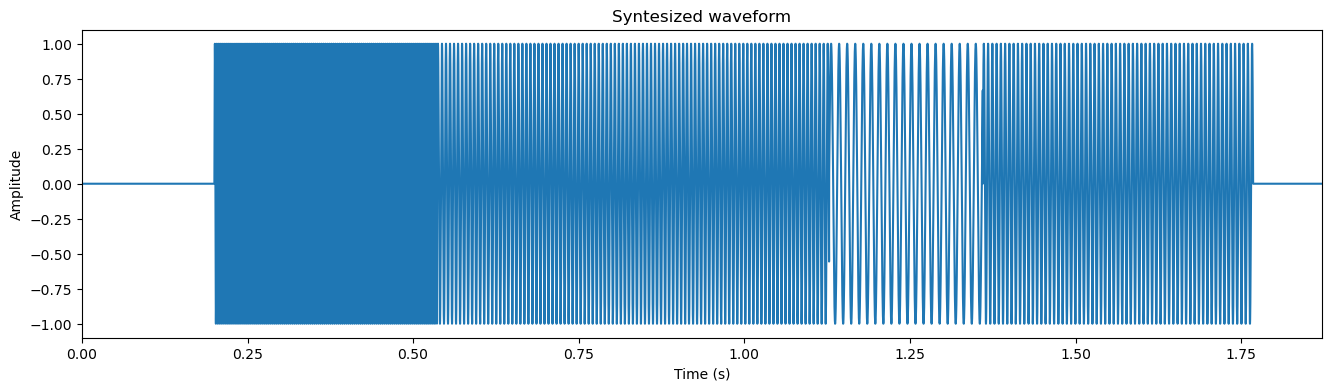

In [50]:
# Create sound object from synthesized pitches
synth_sound = pm.Sound(synth_quant)

# Visualize synthesied waveform
plt.figure(figsize=(16, 4))
plt.title("Syntesized waveform")
plt.plot(synth_sound.xs(), synth_sound.values.T)
plt.xlim([synth_sound.xmin, synth_sound.xmax])
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")

In [51]:
# Create synthesized pitch contour
synth_pitch = synth_sound.to_pitch_ac()

# Select pitch values from Pitch object
synth_pitch_array = synth_pitch.selected_array

# Select frequency from pitch array
synth_pitch_values = synth_pitch_array["frequency"]

# Replace zeros with NaNs
# pitch_values[pitch_values == 0] = np.nan

# Create time variable for x axis
# synth_pitch_time = np.arange(0, len(synth_pitch_array))


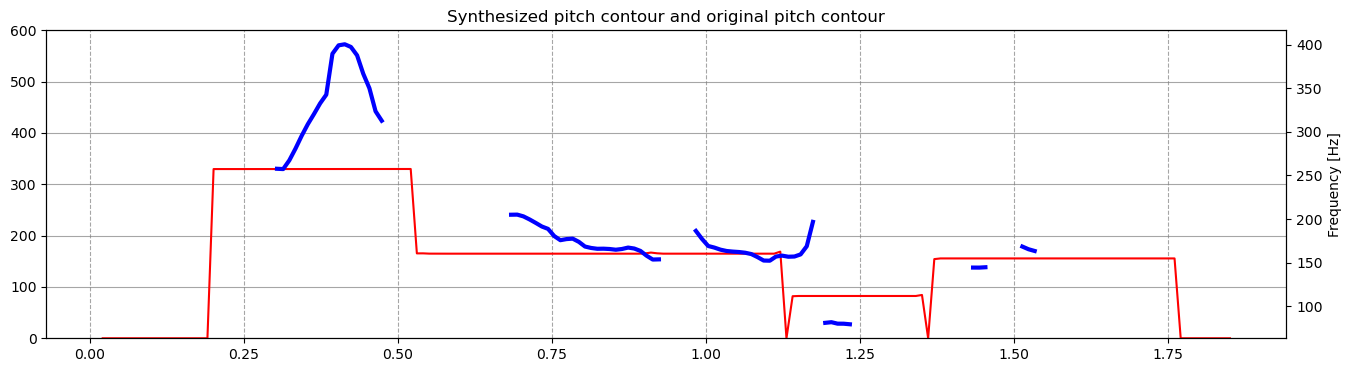

In [52]:
# Visualize onset envelope with pitch
fig, ax1 = plt.subplots(figsize=(16, 4))


# Create first plot: synthesized pitch
ax1.plot(synth_pitch.xs(), synth_pitch_values, color="r", label="Synthesized pitch contour")
ax1.set_ylim(0, synth_pitch.ceiling)

# Plot pitch on the second y-axis (right)
ax2 = ax1.twinx()
ax2.plot(pitch.xs(), pitch_values, '-', linewidth=3, color='b', label="Original pitch contour")
ax2.set_ylabel("Frequency [Hz]")

# Display the plot
plt.title("Synthesized pitch contour and original pitch contour")
# Add grid lines (vertical and horizontal)
ax1.grid(True, which='both', axis='x', linestyle='--', color='gray', alpha=0.7)  # Vertical grid lines
ax1.grid(True, which='both', axis='y', linestyle='-', color='gray', alpha=0.7)  # Horizontal grid lines
plt.show()

A két "lyuk" a jelben, amikor 0-ra sülyed egy-egy pillanatra a frekvencia, valahogy a szintetizálás közben keletkezhetett, az eredeti input jelben nincs benne. Íme az alábbi történhet:

#### I think this is a typical example of "spectral leakage" - When frequency suddenly dips to 0, there are two "holes" in the signal, it is the result of segmentation, that is why Hanning windows are used

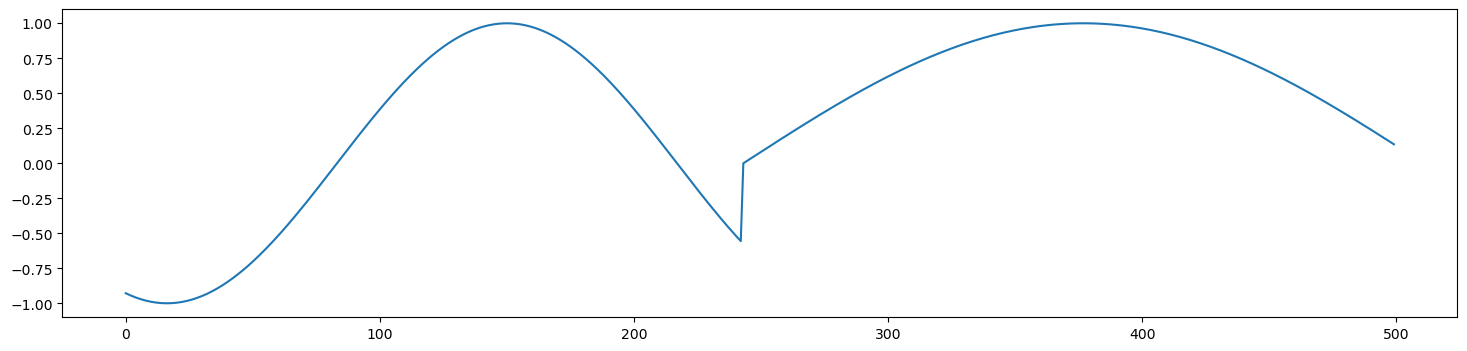

In [ ]:
# this causes the problem
plt.figure(figsize=(18, 4))
plt.plot(synth_quant[49500:50000])
plt.show()

In [ ]:
# Save the audio file
sf.write("synth_quant.wav", synth_quant, samplerate=44100)

### Not try synthesizing the sound from only the MIDI ----- didn't work:(

In [ ]:
############################# DEFUNCT #############################
import mido
# Function to create MIDI file from array of MIDI notes
def create_midi_audio(input_midi, audio_data, time, segment_boundaries, output_midi="melody.mid"):
    # max_idx = len(input_midi) - 1
    # segment_boundaries = [x for x in segment_boundaries if x <= max_idx]
    
    mid = mido.MidiFile(ticks_per_beat=480)
    track = mido.MidiTrack()
    mid.tracks.append(track)
    ppq=480
    # Calculate tempo
    sampling_rate=44100
    tempo = lr.feature.tempo(y=audio_data, sr=sampling_rate)
    print("Tempo: ", tempo)
    # Convert nans to 0
    input_midi = np.nan_to_num(input_midi, nan=0)

    for i in range(len(segment_boundaries) - 1):
        start_idx = segment_boundaries[i]
        end_idx = segment_boundaries[i + 1]

        # Get the MIDI note for this segment, from the full-length MIDI array (including silence represented by 0)
        note = int(input_midi[i])
        
        # Calculate the duration of the note in seconds
        duration = (end_idx - start_idx) / sampling_rate
        print(f"Segment {i}: Start {start_idx}, End {end_idx}, Duration: {time[end_idx] - time[start_idx]:.4f}s")
        # Convert duration from seconds to MIDI ticks (assuming 480 ticks per beat)
        ticks = int((duration * tempo * ppq) / 60)
        print(f"Ticks {ticks}")
        # Handle silence (0 value) and note events
        if note > 0:  # Non-zero note (regular sound)
            print(f"✅ Note: {note}, Start Time: {time[start_idx]:.2f}s, "
                  f"Duration: {duration:.2f}s, Ticks: {ticks}")
            track.append(mido.Message('note_on', note=note, velocity=64, time=0))  # Note on
            track.append(mido.Message('note_off', note=note, velocity=64, time=ticks))  # Note off
        else:  # Silence (0 value)
            print(f"⏳ Skipping silence at {time[start_idx]:.2f}s")
            # If silence is present, we still need to add a time interval in the MIDI track.
            # No note on/off event, but we add the duration as a "rest".
            track.append(mido.Message('note_off', note=0, velocity=0, time=ticks))  # No note event, just a rest.

    mid.save(output_midi)
    print(f"MIDI file saved as {output_midi}")
    return output_midi

midi_out = create_midi_audio(input_midi=midi_notes_rounded, audio_data=y,
                             time=time, segment_boundaries=segment_boundaries
                             )


### Próbáljuk meg direkt MIDI file-á alakítani a kvantizált frekvencia értékeket és utána javítani a minőséget

#### Let's try to convert the qunatized pitches directly to MIDI, then enhance the quality

Let's repeat the whole process just for clarity

In [ ]:
# Open audio with parselmouth and create parselmouth sound object
sound = pm.Sound("data/Herpai_Julia_eso_24.wav")

# Extract pitch
pitch = sound.to_pitch_ac(very_accurate=True, voicing_threshold=0.45, voiced_unvoiced_cost=0.14)

# Extract times (in seconds)
time_pitch = pitch.xs()
# Extract pitch values
pitch_values = pitch.selected_array["frequency"]
pitch_values[pitch_values == 0] = np.nan
# Extract intensity curve
intensity = sound.to_intensity()
# Get intensity value
intensity_values = np.array(intensity.values).flatten()
# Calculate intensity times
time = np.array(intensity.xs()) # It is important to create the time axis from intensity, else results in "index out of bounds" error

# Find the local minima (troughs) of the intensity curve (RMS)
# 'order=5' means we'll look for minima that have at least 5 neighbors (actually 15 worked better)
troughs = argrelextrema(intensity_values, np.less_equal, order=15)[0]

# Create segment boundaries
segment_boundaries = np.concatenate([[0], troughs, [len(time)-1]])


In [59]:
# Calculate median pitch in each segment
median_pitches = []

for i in range(len(segment_boundaries) - 1):
    # Set segment start and end points
    segment_start = time[segment_boundaries][i]
    segment_end = time[segment_boundaries][i+1]
    
    # Calculate segment indices -- np.where() returns indices where the defined conditions are true
    segment_indices = np.where((pitch.xs() >= segment_start) & (pitch.xs() < segment_end))
    segment_pitches = pitch_values[segment_indices]
    
    # Calculate nanmedian pitch in segment
    if len(segment_pitches) > 0: # contains at least 1 non-nan value
        median_pitch = np.nanmedian(segment_pitches)
    else:
        median_pitch = 0
    
    # Append aggregated pitch value to list
    median_pitches.append(median_pitch)
    

for i in median_pitches:
    print(i)

nan
328.4059533070089
171.04896426468054
161.27203470506464
80.51618772326623
153.99811687911966
nan


C:\Users\Nagy Sándor Imre\AppData\Local\Temp\ipykernel_3360\2929843145.py:15: RuntimeWarning: All-NaN slice encountered
  median_pitch = np.nanmedian(segment_pitches)


In [60]:
# Convert pitch values to MIDI
midi_notes = lr.hz_to_midi(median_pitches)

# Round midi notes to the nearest semitone
midi_notes_rounded = np.round(midi_notes)

# Convert back to Hz -- this step is not necessary for sound playback 
quantized_pitches = lr.midi_to_hz(midi_notes_rounded)

In [65]:
# Import midiutil
from midiutil import MIDIFile

# Replace NaN with 0 (rests)
midi_notes_rounded = np.nan_to_num(midi_notes_rounded, nan=0).astype(int)
sampling_rate = 44100
timestamps = time

# Calculate tempo with librosa -- load audio with librosa as well!
filename = "C:/Users/Nagy Sándor Imre/OneDrive - Pécsi Tudományegyetem/ELKH/ProsRead/data/stimlist/audiofiles/Herpai_Julia_eso_24.waw.wav"
# Load the audio and store it as a numpy array
y, sr = lr.load(filename, sr=None)
tempo = lr.feature.tempo(y=y, sr=sr)
bps = tempo / 60 # beats per second

# Create MIDI file
midi = MIDIFile(1)  # One track
track = 0
time = 0  # Start time
midi.addTempo(track, time, tempo)

# Add notes
for i in range(len(segment_boundaries) -1):
    print("First iteration: ")
    note = midi_notes_rounded[i]
    print("Midi note: ", note)
    # Convert index difference to seconds
    start_idx = segment_boundaries[i]
    end_idx = segment_boundaries[i+1]
    
    duration_seconds = timestamps[end_idx] - timestamps[start_idx] # another solution might be: (end_idx - start_idx) / sampling_rate
    # duration_seconds = (segment_boundaries[i + 1] - segment_boundaries[i]) / sampling_rate #time[end_idx] - time[start_idx]
    print("Duration in seconds: ", duration_seconds)
    # Convert to beats
    duration_beats = duration_seconds * bps
    print("Duration in beats: ", duration_beats)
    if note > 0:  # Play note
        midi.addNote(track, 0, note, time, duration_beats, 100)
    
    time += duration_beats  # Move time forward

# Write to file
with open("output.mid", "wb") as f:
    midi.writeFile(f)

print("MIDI file created: output.mid")

First iteration: 
Midi note:  0
Duration in seconds:  0.2
Duration in beats:  [0.52201705]
First iteration: 
Midi note:  64
Duration in seconds:  0.336
Duration in beats:  [0.87698864]
First iteration: 
Midi note:  53
Duration in seconds:  0.376
Duration in beats:  [0.98139205]
First iteration: 
Midi note:  52
Duration in seconds:  0.2160000000000002
Duration in beats:  [0.56377841]
First iteration: 
Midi note:  40
Duration in seconds:  0.23199999999999976
Duration in beats:  [0.60553977]
First iteration: 
Midi note:  51
Duration in seconds:  0.4079999999999999
Duration in beats:  [1.06491477]
First iteration: 
Midi note:  0
Duration in seconds:  0.10400000000000009
Duration in beats:  [0.27144886]
MIDI file created: output.mid


#### Two audio files that are potentially useful for synthesis:
- median_pitches - as pitch
- synth_quant - as MIDI

TODO
Extract:
- harmonics to noise ratio
- jitter (cycle-to-cycle variation in f0) - indicates voice stability
- shimmer (cycle-to-cyle variation in amplitue)
- tempo/beat
- duration